In [1]:
import numpy as np
import pandas as pd
import os

In [2]:
import io
import re
from pathlib import Path

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)

DATA = Path(r"C:\Users\Atharv\Projects\Yonkers-Bond-Scraper\Data Scraper\HTML\Data.html")           # your pasted bundle
OUT = Path("output_data"); OUT.mkdir(exist_ok=True)

print("exists:", DATA.exists(), "|", f"{DATA.stat().st_size:,} bytes" if DATA.exists() else "")

exists: True | 342,669 bytes


## Helpers

In [3]:
MARKER = re.compile(r"<!--\s*SERIES:\s*(.*?)\s*-->", re.I | re.S)
INFO_RE = re.compile(r"Displaying\s+([\d,]+)\s+to\s+([\d,]+)\s+of\s+([\d,]+)\s+results?", re.I)

CANONICAL = ["cusip_img", "principal", "security_description", "coupon",
             "maturity_date", "initial_price_yield", "initial_price", "initial_yield"]


def _num(s):
    return pd.to_numeric(
        s.astype(str).str.replace(r"[,$%]", "", regex=True).str.strip()
                     .replace({"-": np.nan, "": np.nan, "nan": np.nan}),
        errors="coerce")


def _flatten(cols):
    if isinstance(cols, pd.MultiIndex):
        return [" ".join(str(p) for p in c if "Unnamed" not in str(p)).strip() for c in cols]
    return [str(c).strip() for c in cols]


def _parse_marker(text):
    """name | dated_date | (par amount OR maturity range e.g. 2028-2046)"""
    parts = [p.strip() for p in text.split("|")]
    out = {"series_name": parts[0] if parts else "UNLABELLED",
           "dated_date": pd.NaT, "stated_par": np.nan,
           "exp_first_year": np.nan, "exp_last_year": np.nan}
    if len(parts) > 1 and parts[1]:
        out["dated_date"] = pd.to_datetime(parts[1], errors="coerce")
    if len(parts) > 2 and parts[2]:
        rng = re.match(r"^\s*(\d{4})\s*(?:to|-|–)\s*(\d{4})\s*$", parts[2], re.I)
        if rng:
            out["exp_first_year"], out["exp_last_year"] = int(rng.group(1)), int(rng.group(2))
        else:
            out["stated_par"] = pd.to_numeric(re.sub(r"[^0-9.]", "", parts[2]), errors="coerce")
    return out


def _expected_count(block_html):
    """DataTables' 'Displaying X to Y of N results' — the authoritative row count."""
    hits = INFO_RE.findall(block_html)
    if not hits:
        return np.nan
    return max(int(h[2].replace(",", "")) for h in hits)


def _parse_block(html):
    """Merge every scale table in the block — one per page of a paginated table."""
    tables = pd.read_html(io.StringIO(html), flavor="lxml")
    if not tables:
        raise ValueError("no <table> in block")

    frames = []
    for t in tables:
        t = t.copy()
        t.columns = _flatten(t.columns)
        if t.shape[1] < len(CANONICAL) or len(t) == 0:
            continue
        t = t.iloc[:, :len(CANONICAL)]
        t.columns = CANONICAL
        frames.append(t)

    if not frames:
        raise ValueError("no scale-shaped table in block")

    df = pd.concat(frames, ignore_index=True)
    for c in ("principal", "coupon", "initial_price", "initial_yield"):
        df[c] = _num(df[c])
    df["maturity_date"] = pd.to_datetime(df["maturity_date"], errors="coerce")

    df = df.drop(columns=["cusip_img"])
    df = df[df["principal"].notna()]
    n_before = len(df)
    df = df.drop_duplicates(subset=["maturity_date", "principal"])

    df = df.sort_values("maturity_date").reset_index(drop=True)
    df.attrs["n_pages"] = len(frames)
    df.attrs["n_dupes_dropped"] = n_before - len(df)
    return df


def parse_bundle(path, verbose=True):
    raw = Path(path).read_text(encoding="utf-8", errors="ignore")

    marks = list(MARKER.finditer(raw))
    if not marks:
        raise ValueError("No <!--SERIES: ...--> markers found.")

    for m in marks:
        if "<table" in m.group(1).lower():
            raise ValueError(
                f"Malformed marker — missing closing '-->' near: {m.group(1)[:60]!r}")

    mats, issues = [], []
    for i, m in enumerate(marks):
        meta = _parse_marker(m.group(1))
        end = marks[i + 1].start() if i + 1 < len(marks) else len(raw)
        block = raw[m.end():end]

        try:
            t = _parse_block(block)
        except Exception as e:
            print(f"  {meta['series_name']}: FAILED — {e}")
            continue

        t["series_name"] = meta["series_name"]
        t["dated_date"] = meta["dated_date"]
        mats.append(t)

        yrs = sorted(t["maturity_date"].dt.year.dropna().astype(int))
        first, last = (yrs[0], yrs[-1]) if yrs else (np.nan, np.nan)
        gaps = [y for y in range(first, last + 1) if y not in yrs] if yrs else []
        expected = _expected_count(block)

        rec = {**meta,
               "n_maturities": len(t), "n_pages": t.attrs["n_pages"],
               "expected_rows": expected,
               "parsed_par": t["principal"].sum(),
               "first_year": first, "last_year": last, "gap_years": gaps,
               "coupon_min": t["coupon"].min(), "coupon_max": t["coupon"].max(),
               "yield_min": t["initial_yield"].min(), "yield_max": t["initial_yield"].max(),
               "n_below_par": int((t["initial_price"] < 100).sum())}

        flags = []
        if pd.notna(expected):
            rec["count_ok"] = int(expected) == len(t)
            if not rec["count_ok"]:
                flags.append(f"COUNT expected {int(expected)}, got {len(t)}")
        else:
            flags.append("no 'Displaying N results' line — copy the wrapper div, not just the table")

        if pd.notna(meta["exp_first_year"]):
            rec["range_ok"] = (first == meta["exp_first_year"] and last == meta["exp_last_year"])
            if not rec["range_ok"]:
                flags.append(f"RANGE expected {meta['exp_first_year']}-{meta['exp_last_year']}, "
                             f"got {first}-{last}")

        if pd.notna(meta["stated_par"]):
            rec["variance"] = rec["parsed_par"] - meta["stated_par"]
            rec["reconciles"] = abs(rec["variance"]) < 1.0
            if not rec["reconciles"]:
                flags.append(f"PAR {rec['variance']:+,.0f}")

        if gaps:
            flags.append(f"GAPS {gaps}")
        if t.attrs["n_dupes_dropped"]:
            flags.append(f"dropped {t.attrs['n_dupes_dropped']} duplicate rows")

        issues.append(rec)

        if verbose:
            pg = f", {t.attrs['n_pages']} pages" if t.attrs["n_pages"] > 1 else ""
            print(f"  {meta['series_name']}: {len(t)} maturities, "
                  f"${rec['parsed_par']:,.0f}{pg}"
                  + ("  !! " + " | ".join(flags) if flags else "  OK"))

    maturities = pd.concat(mats, ignore_index=True) if mats else pd.DataFrame()
    issues_df = pd.DataFrame(issues)

    if verbose and not issues_df.empty:
        print(f"\n{len(issues_df)} issues | {len(maturities)} maturities | "
              f"${issues_df['parsed_par'].sum():,.0f}")

    return maturities, issues_df

## Parse

In [4]:
maturities, issues = parse_bundle(DATA)

cols = [c for c in ["series_name", "dated_date", "n_maturities", "expected_rows",
                    "count_ok", "n_pages", "parsed_par", "first_year", "last_year",
                    "range_ok", "stated_par", "variance", "reconciles", "gap_years"]
        if c in issues.columns]
issues[cols]

  GENERAL OBLIGATION SERIAL BONDS-2026A: 19 maturities, $89,295,000  !! no 'Displaying N results' line — copy the wrapper div, not just the table
  SCHOOL SERIAL BONDS-2026B: 19 maturities, $25,185,000, 2 pages  !! no 'Displaying N results' line — copy the wrapper div, not just the table
  GENERAL OBLIGATION SERIAL BONDS-2026C (FEDERALLY TAXABLE): 10 maturities, $7,080,000  !! no 'Displaying N results' line — copy the wrapper div, not just the table
  GENERAL OBLIGATION REFUNDING BONDS-2026D: 10 maturities, $56,870,000  !! no 'Displaying N results' line — copy the wrapper div, not just the table
  GENERAL OBLIGATION BOND ANTICIPATION NOTES-2025: 1 maturities, $5,500,000  !! no 'Displaying N results' line — copy the wrapper div, not just the table
  GENERAL OBLIGATION BOND ANTICIPATION NOTES - 2024A: 1 maturities, $3,000,000  !! no 'Displaying N results' line — copy the wrapper div, not just the table
  SCHOOL SERIAL BONDS-2024C: 20 maturities, $13,765,000, 2 pages  !! no 'Displaying N 

C:\Users\Atharv\AppData\Local\Temp\ipykernel_7244\1379234294.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace({"-": np.nan, "": np.nan, "nan": np.nan}),
C:\Users\Atharv\AppData\Local\Temp\ipykernel_7244\1379234294.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace({"-": np.nan, "": np.nan, "nan": np.nan}),
C:\Users\Atharv\AppData\Local\Temp\ipykernel_7244\1379234294.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, expl

,series_name,dated_date,n_maturities,expected_rows,n_pages,parsed_par,first_year,last_year,range_ok,stated_par,gap_years
0,GENERAL OBLIGATION SERIAL BONDS-2026A,2026-02-18,19,NaN,1,89295000.0,2028.0,2046.0,True,NaN,[]
1,SCHOOL SERIAL BONDS-2026B,2026-02-18,19,NaN,2,25185000.0,2028.0,2046.0,True,NaN,[]
2,GENERAL OBLIGATION SERIAL BONDS-2026C (FEDERAL...,2026-02-18,10,NaN,1,7080000.0,2027.0,2036.0,True,NaN,[]
3,GENERAL OBLIGATION REFUNDING BONDS-2026D,2026-02-18,10,NaN,1,56870000.0,2026.0,2035.0,True,NaN,[]
4,GENERAL OBLIGATION BOND ANTICIPATION NOTES-2025,2025-12-04,1,NaN,1,5500000.0,2026.0,2026.0,True,NaN,[]
5,GENERAL OBLIGATION BOND ANTICIPATION NOTES - 2...,2024-12-06,1,NaN,1,3000000.0,2025.0,2025.0,True,NaN,[]
6,SCHOOL SERIAL BONDS-2024C,2024-09-27,20,NaN,2,13765000.0,2025.0,2044.0,True,NaN,[]
7,GENERAL OBLIGATION SERIAL BONDS-2024D (FEDERAL...,2024-09-27,9,NaN,1,11455000.0,2025.0,2033.0,True,NaN,[]
8,GENERAL OBLIGATION SERIAL BONDS - 2024A,2024-02-21,17,NaN,2,55680000.0,2026.0,2042.0,True,NaN,[]
9,SCHOOL SERIAL BONDS - 2024 B,2024-02-21,19,NaN,2,26805000.0,2026.0,2044.0,True,NaN,[]


## Classify

In [5]:
NOTE_RE = re.compile(r"\b(?:bond anticipation|revenue anticipation|tax anticipation|BAN|RAN|TAN|notes?)\b", re.I)
REFUND_RE = re.compile(r"\brefund(?:ing|ed)?\b", re.I)
TAXABLE_RE = re.compile(r"\btaxable\b", re.I)
SCHOOL_RE = re.compile(r"\b(?:school|sch-ser)\b", re.I)

def classify(df):
    out = df.copy()
    name = out["series_name"].fillna("")
    out["is_note"] = name.str.contains(NOTE_RE)
    out["is_refunding"] = name.str.contains(REFUND_RE)
    out["is_taxable"] = name.str.contains(TAXABLE_RE)
    out["is_school"] = name.str.contains(SCHOOL_RE)
    out["instrument"] = np.where(out["is_note"], "Note", "Bond")
    out["money_type"] = np.where(out["is_refunding"], "Refunding", "New money")
    out["purpose"] = np.select(
        [out["is_refunding"], out["is_school"]],
        ["Refunding", "School"], default="General / public improvement")
    out["year"] = pd.to_datetime(out["dated_date"]).dt.year
    return out

issues = classify(issues)
maturities = maturities.merge(
    issues[["series_name", "instrument", "money_type", "purpose",
            "is_taxable", "is_school", "year"]],
    on="series_name", how="left")

issues[["series_name", "year", "instrument", "money_type", "purpose", "is_taxable"]]

,series_name,year,instrument,money_type,purpose,is_taxable
0,GENERAL OBLIGATION SERIAL BONDS-2026A,2026,Bond,New money,General / public improvement,False
1,SCHOOL SERIAL BONDS-2026B,2026,Bond,New money,School,False
2,GENERAL OBLIGATION SERIAL BONDS-2026C (FEDERAL...,2026,Bond,New money,General / public improvement,True
3,GENERAL OBLIGATION REFUNDING BONDS-2026D,2026,Bond,Refunding,Refunding,False
4,GENERAL OBLIGATION BOND ANTICIPATION NOTES-2025,2025,Note,New money,General / public improvement,False
5,GENERAL OBLIGATION BOND ANTICIPATION NOTES - 2...,2024,Note,New money,General / public improvement,False
6,SCHOOL SERIAL BONDS-2024C,2024,Bond,New money,School,False
7,GENERAL OBLIGATION SERIAL BONDS-2024D (FEDERAL...,2024,Bond,New money,General / public improvement,True
8,GENERAL OBLIGATION SERIAL BONDS - 2024A,2024,Bond,New money,General / public improvement,False
9,SCHOOL SERIAL BONDS - 2024 B,2024,Bond,New money,School,False


In [6]:
problems = []

if "range_ok" in issues:
    for _, r in issues[issues["range_ok"] == False].iterrows():
        problems.append(f"{r['series_name']}: range mismatch")
if "reconciles" in issues:
    for _, r in issues[issues["reconciles"] == False].iterrows():
        problems.append(f"{r['series_name']}: par off by {r['variance']:+,.0f}")
for _, r in issues[issues["gap_years"].astype(bool)].iterrows():
    problems.append(f"{r['series_name']}: gap years {r['gap_years']}")

single = issues[(issues["n_pages"] == 1) & (issues["last_year"] - issues["first_year"] >= 10)]
for _, r in single.iterrows():
    problems.append(f"{r['series_name']}: {r['first_year']}-{r['last_year']} on one page — verify pagination")

for c in ["principal", "coupon", "maturity_date"]:
    n = maturities[c].isna().sum()
    if n:
        problems.append(f"{n} rows missing {c}")

print("\n".join(f"  !! {p}" for p in problems) if problems else "  no problems found")
print(f"\n{len(issues)} issues | {len(maturities)} maturities | ${issues['parsed_par'].sum():,.0f}")

  !! SCH-SER D: range mismatch
  !! SCHOOL SERIAL BONDS 2022D: gap years [2039, 2040, 2041]
  !! GENERAL OBLIGATION SERIAL BONDS-2026A: 2028.0-2046.0 on one page — verify pagination
  !! GENERAL OBLIGATION SERIAL BONDS 2022C: 2024.0-2038.0 on one page — verify pagination
  !! SCHOOL SERIAL BONDS 2022D: 2024.0-2042.0 on one page — verify pagination
  !! GENERAL OBLIGATION SERIAL BONDS-2021A: 2023.0-2036.0 on one page — verify pagination
  !! SCHOOL SERIAL BONDS-2021B: 2023.0-2041.0 on one page — verify pagination

23 issues | 265 maturities | $641,252,940


In [7]:
by_year = (issues.groupby("year")
           .apply(lambda d: pd.Series({
               "n_issues": len(d),
               "n_bonds": (~d["is_note"]).sum(),
               "n_notes": d["is_note"].sum(),
               "par_total": d["parsed_par"].sum(),
               "par_new_money": d.loc[~d["is_refunding"] & ~d["is_note"], "parsed_par"].sum(),
               "par_refunding": d.loc[d["is_refunding"], "parsed_par"].sum(),
               "par_notes": d.loc[d["is_note"], "parsed_par"].sum(),
               "par_school": d.loc[d["is_school"], "parsed_par"].sum(),
               "par_taxable": d.loc[d["is_taxable"], "parsed_par"].sum(),
           }), include_groups=False)
           .reset_index())

out = issues.copy()
out["gap_years"] = out["gap_years"].apply(lambda g: ";".join(map(str, g)) if g else "")

for df, name in [(maturities, "yonkers_maturities.csv"),
                 (out, "yonkers_issues.csv"),
                 (by_year, "yonkers_by_year.csv")]:
    p = OUT / name
    df.to_csv(p, index=False)
    print(f"{p}  ({p.stat().st_size:,} bytes)")

by_year

output_data\yonkers_maturities.csv  (39,663 bytes)
output_data\yonkers_issues.csv  (4,523 bytes)
output_data\yonkers_by_year.csv  (516 bytes)


,year,n_issues,n_bonds,n_notes,par_total,par_new_money,par_refunding,par_notes,par_school,par_taxable
0,2020,1.0,0.0,1.0,65000000.0,0.0,0.0,65000000.0,0.0,0.0
1,2021,3.0,3.0,0.0,67175000.0,67175000.0,0.0,0.0,33175000.0,6095000.0
2,2022,8.0,8.0,0.0,202985000.0,161940000.0,41045000.0,0.0,31050000.0,7080000.0
3,2024,6.0,4.0,2.0,122162940.0,107705000.0,0.0,14457940.0,40570000.0,11455000.0
4,2025,1.0,0.0,1.0,5500000.0,0.0,0.0,5500000.0,0.0,0.0
5,2026,4.0,4.0,0.0,178430000.0,121560000.0,56870000.0,0.0,25185000.0,7080000.0


## Analysis And Visualization

In [12]:
df=pd.read_csv('output_data/yonkers_maturities.csv')
df

,principal,security_description,coupon,maturity_date,initial_price_yield,initial_price,initial_yield,series_name,dated_date,instrument,money_type,purpose,is_taxable,is_school,year
0,2925000.0,SER A,5.00,2028-02-01,-,105.125,2.30,GENERAL OBLIGATION SERIAL BONDS-2026A,2026-02-18,Bond,New money,General / public improvement,False,False,2026
1,3075000.0,SER A,5.00,2029-02-01,-,107.753,2.27,GENERAL OBLIGATION SERIAL BONDS-2026A,2026-02-18,Bond,New money,General / public improvement,False,False,2026
2,3225000.0,SER A,5.00,2030-02-01,-,110.065,2.32,GENERAL OBLIGATION SERIAL BONDS-2026A,2026-02-18,Bond,New money,General / public improvement,False,False,2026
3,3385000.0,SER A,5.00,2031-02-01,-,112.022,2.41,GENERAL OBLIGATION SERIAL BONDS-2026A,2026-02-18,Bond,New money,General / public improvement,False,False,2026
4,3555000.0,SER A,5.00,2032-02-01,-,113.865,2.48,GENERAL OBLIGATION SERIAL BONDS-2026A,2026-02-18,Bond,New money,General / public improvement,False,False,2026
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260,680000.0,TAXABLE-SER C,1.60,2028-02-15,-,100.000,1.60,GENERAL OBLIGATION SERIAL BONDS-2021C (FEDERAL...,2021-02-16,Bond,New money,General / public improvement,True,False,2021
261,695000.0,TAXABLE-SER C,1.75,2029-02-15,-,100.000,1.75,GENERAL OBLIGATION SERIAL BONDS-2021C (FEDERAL...,2021-02-16,Bond,New money,General / public improvement,True,False,2021
262,705000.0,TAXABLE-SER C,1.87,2030-02-15,-,100.000,1.87,GENERAL OBLIGATION SERIAL BONDS-2021C (FEDERAL...,2021-02-16,Bond,New money,General / public improvement,True,False,2021
263,720000.0,TAXABLE-SER C,2.00,2031-02-15,-,100.000,2.00,GENERAL OBLIGATION SERIAL BONDS-2021C (FEDERAL...,2021-02-16,Bond,New money,General / public improvement,True,False,2021


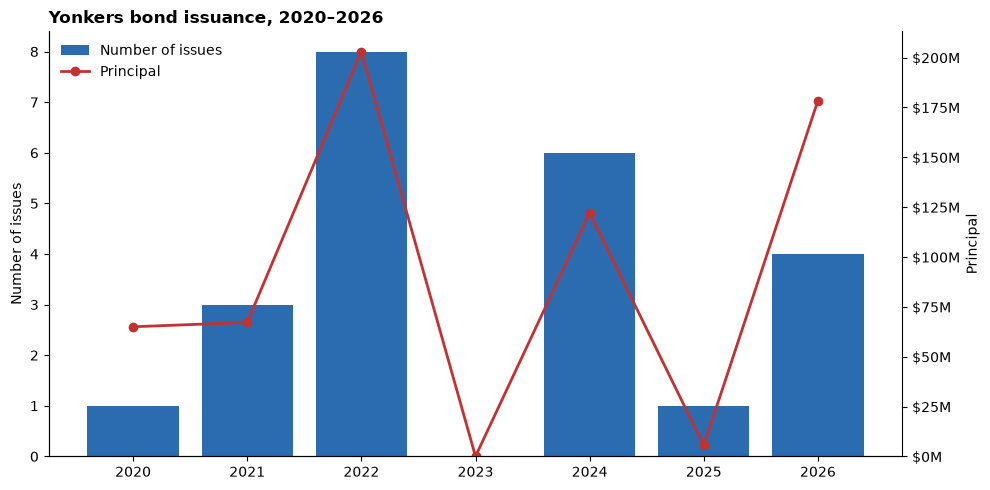

,year,n_issues,principal
0,2020,1,65000000.0
1,2021,3,67175000.0
2,2022,8,202985000.0
3,2023,0,0.0
4,2024,6,122162940.0
5,2025,1,5500000.0
6,2026,4,178430000.0


In [16]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

issues["year"] = pd.to_datetime(issues["dated_date"]).dt.year
issues["is_note"] = issues["series_name"].str.contains("ANTICIPATION NOTES", case=False)

summary = (issues.groupby("year")
           .agg(n_issues=("series_name", "size"), principal=("parsed_par", "sum"))
           .reindex(range(issues["year"].min(), issues["year"].max() + 1), fill_value=0)
           .rename_axis("year").reset_index())

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(summary))
ax.bar(x, summary["n_issues"], color="#2b6cb0", label="Number of issues")
ax.set_xticks(x); ax.set_xticklabels(summary["year"])
ax.set_ylabel("Number of issues")
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.spines[["top", "right"]].set_visible(False)

ax2 = ax.twinx()
ax2.plot(x, summary["principal"], color="#c53030", marker="o", lw=2, label="Principal")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v/1e6:,.0f}M"))
ax2.set_ylabel("Principal"); ax2.set_ylim(bottom=0)
ax2.spines[["top"]].set_visible(False)

h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="upper left", frameon=False)
ax.set_title("Yonkers bond issuance, 2020–2026", fontweight="bold", loc="left")
fig.tight_layout()
fig.savefig(OUT / "issuance.png", dpi=150)
plt.show()

summary

In [17]:
bonds = issues[~issues["is_note"]]
notes = issues[issues["is_note"]]
empty = summary[summary["n_issues"] == 0]["year"].tolist()
peak = summary.loc[summary["principal"].idxmax()]
big = issues.nlargest(3, "parsed_par")

print(f"""
{len(issues)} issues, {issues['year'].min()}–{issues['year'].max()}, ${issues['parsed_par'].sum():,.0f} total.

Bonds: {len(bonds)} issues, ${bonds['parsed_par'].sum():,.0f}
Notes: {len(notes)} issues, ${notes['parsed_par'].sum():,.0f}

Busiest year: {int(peak['year'])} — {int(peak['n_issues'])} issues, ${peak['principal']:,.0f}
No issuance in: {', '.join(map(str, empty)) or 'none'}

Largest issues:""")
for r in big.itertuples():
    print(f"  {r.series_name}  ${r.parsed_par:,.0f}")

print(f"""
By year:
{summary.to_string(index=False)}
""")


23 issues, 2020–2026, $641,252,940 total.

Bonds: 19 issues, $556,295,000
Notes: 4 issues, $84,957,940

Busiest year: 2022 — 8 issues, $202,985,000
No issuance in: 2023

Largest issues:
  GENERAL OBLIGATION SERIAL BONDS-2026A  $89,295,000
  GENERAL OBLIGATION SERIAL BONDS-2022F  $67,820,000
  REVENUE ANTICIPATION NOTES-2020/2021  $65,000,000

By year:
 year  n_issues   principal
 2020         1  65000000.0
 2021         3  67175000.0
 2022         8 202985000.0
 2023         0         0.0
 2024         6 122162940.0
 2025         1   5500000.0
 2026         4 178430000.0

